In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("insurance_claims.csv")
df.head()
df.shape
df.info()
df.isnull().sum()

Saving insurance_claims.csv to insurance_claims (3).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation   

,0
months_as_customer,0
age,0
policy_number,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0


In [11]:
df.columns
df = df.drop(['policy_number','policy_bind_date','insured_zip','incident_location','incident_date','auto_model'], axis=1)

df.head()

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_year,fraud_reported,_c39
0,328,48,OH,250/500,1000,1406.91,0,MALE,MD,craft-repair,...,2,YES,71610,6510,13020,52080,Saab,2004,Y,NaN
1,228,42,IN,250/500,2000,1197.22,5000000,MALE,MD,machine-op-inspct,...,0,?,5070,780,780,3510,Mercedes,2007,Y,NaN
2,134,29,OH,100/300,2000,1413.14,5000000,FEMALE,PhD,sales,...,3,NO,34650,7700,3850,23100,Dodge,2007,N,NaN
3,256,41,IL,250/500,2000,1415.74,6000000,FEMALE,PhD,armed-forces,...,2,NO,63400,6340,6340,50720,Chevrolet,2014,Y,NaN
4,228,44,IL,500/1000,1000,1583.91,6000000,MALE,Associate,sales,...,1,NO,6500,1300,650,4550,Accura,2009,N,NaN


In [12]:
df['fraud_reported'] = df['fraud_reported'].map({'Y':1,'N':0})

df['fraud_reported'].value_counts()

,count
fraud_reported,
0,753
1,247


In [13]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,months_as_customer,age,policy_deductable,policy_annual_premium,umbrella_limit,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,...,auto_make_Dodge,auto_make_Ford,auto_make_Honda,auto_make_Jeep,auto_make_Mercedes,auto_make_Nissan,auto_make_Saab,auto_make_Suburu,auto_make_Toyota,auto_make_Volkswagen
0,328,48,1000,1406.91,0,53300,0,5,1,1,...,False,False,False,False,False,False,True,False,False,False
1,228,42,2000,1197.22,5000000,0,0,8,1,0,...,False,False,False,False,True,False,False,False,False,False
2,134,29,2000,1413.14,5000000,35100,0,7,3,2,...,True,False,False,False,False,False,False,False,False,False
3,256,41,2000,1415.74,6000000,48900,-62400,5,1,1,...,False,False,False,False,False,False,False,False,False,False
4,228,44,1000,1583.91,6000000,66000,-46000,20,1,0,...,False,False,False,False,False,False,False,False,False,False


In [14]:
df.shape

(1000, 107)

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop('fraud_reported', axis=1)
y = df['fraud_reported']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(800, 106)
(200, 106)


In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [17]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.71


In [19]:
import pickle

with open("fraud_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=200, random_state=42)

In [21]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Improved Accuracy:", accuracy)

Improved Accuracy: 0.715


In [23]:
import pickle

with open("fraud_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Exploratory Data Analysis (EDA)

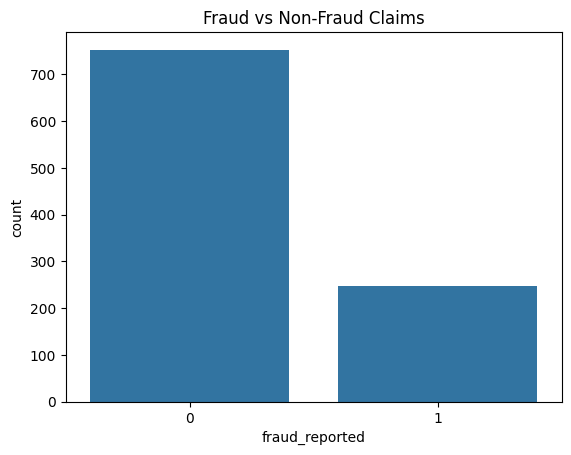

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='fraud_reported', data=df)
plt.title("Fraud vs Non-Fraud Claims")
plt.show()

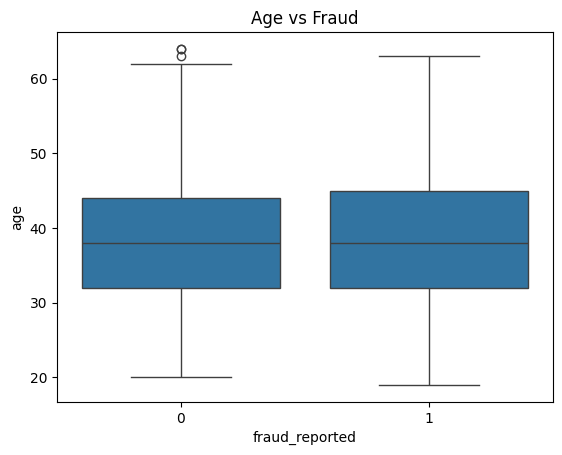

In [25]:
sns.boxplot(x='fraud_reported', y='age', data=df)
plt.title("Age vs Fraud")
plt.show()

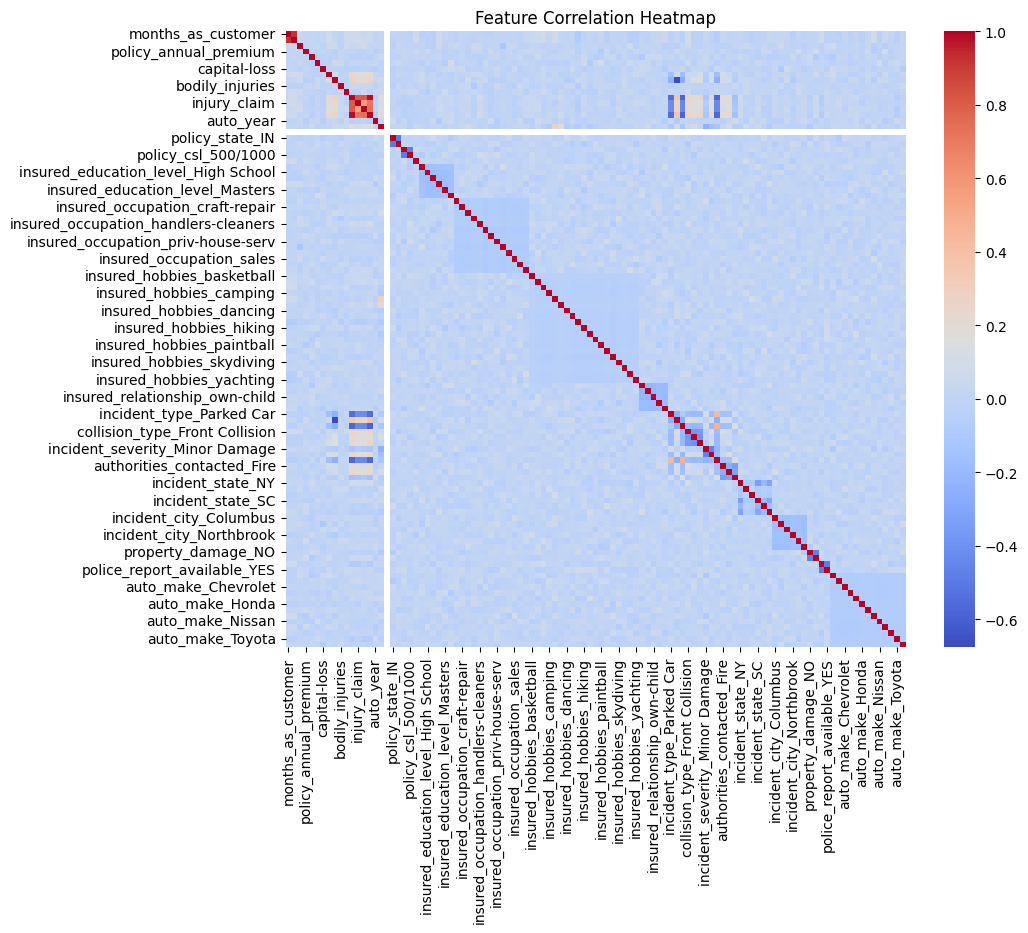

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [29]:
from sklearn.preprocessing import StandardScaler

X = X.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)